# Pandas and 3D Data

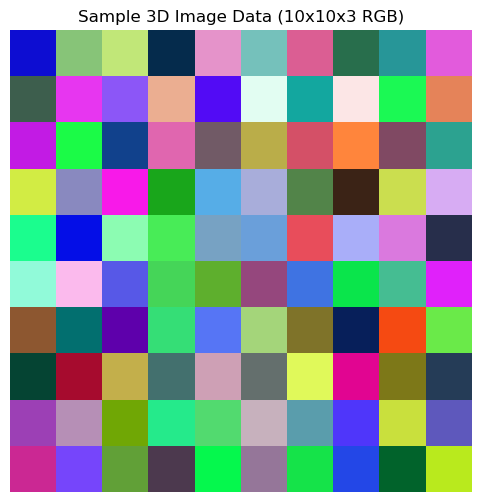

In [31]:
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

# Generate a sample image array (3D: height x width x channels)
image_3d = np.random.randint(0, 256, size=(10, 10, 3), dtype=np.uint8)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image_3d)
plt.title("Sample 3D Image Data (10x10x3 RGB)")
plt.axis('off')
plt.show()

In [32]:
# display the shape and dimensions of the image data as numPy array
print("\nImage shape:", image_3d.shape)
print("Image dimensions:", image_3d.ndim)


Image shape: (10, 10, 3)
Image dimensions: 3


In [33]:
print(image_3d)

[[[ 13  13 210]
  [135 196 120]
  [193 231 120]
  [  5  43  76]
  [229 147 202]
  [117 193 187]
  [219  94 147]
  [ 40 110  76]
  [ 39 150 152]
  [226  91 220]]

 [[ 61  94  77]
  [231  54 240]
  [140  86 247]
  [235 174 145]
  [ 82  11 245]
  [226 253 242]
  [ 19 167 159]
  [252 230 230]
  [ 27 249  84]
  [229 131  89]]

 [[194  27 228]
  [ 27 251  71]
  [ 17  65 140]
  [224 102 175]
  [113  90 102]
  [186 173  73]
  [212  80 103]
  [255 133  60]
  [128  73  99]
  [ 44 162 144]]

 [[210 236  68]
  [137 137 191]
  [248  25 233]
  [ 25 166  27]
  [ 86 173 231]
  [168 173 218]
  [ 82 132  73]
  [ 59  35  22]
  [203 222  79]
  [215 172 243]]

 [[ 27 253 142]
  [  4  14 231]
  [140 252 178]
  [ 72 236  87]
  [119 162 195]
  [106 159 218]
  [232  77  91]
  [169 174 249]
  [218 121 222]
  [ 39  46  75]]

 [[145 250 217]
  [251 186 237]
  [ 87  88 231]
  [ 69 213  88]
  [ 94 175  45]
  [149  71 125]
  [ 63 115 226]
  [ 10 229  75]
  [ 69 189 146]
  [224  33 250]]

 [[141  87  48]
  [  2 111 1

In [37]:
print(image_3d.shape)
print(image_3d[0, 0])      # one pixel
print(image_3d[:, :, 0])   # red channel
print(image_3d[:, :, 1])   # green channel
print(image_3d[:, :, 2])   # blue channel

(10, 10, 3)
[ 13  13 210]
[[ 13 135 193   5 229 117 219  40  39 226]
 [ 61 231 140 235  82 226  19 252  27 229]
 [194  27  17 224 113 186 212 255 128  44]
 [210 137 248  25  86 168  82  59 203 215]
 [ 27   4 140  72 119 106 232 169 218  39]
 [145 251  87  69  94 149  63  10  69 224]
 [141   2  94  53  86 164 127   7 245 106]
 [  5 166 195  67 206 100 224 225 125  37]
 [156 182 112  37  82 199  90  79 201  94]
 [203 118  97  76   5 149  21  35   1 185]]
[[ 13 196 231  43 147 193  94 110 150  91]
 [ 94  54  86 174  11 253 167 230 249 131]
 [ 27 251  65 102  90 173  80 133  73 162]
 [236 137  25 166 173 173 132  35 222 172]
 [253  14 252 236 162 159  77 174 121  46]
 [250 186  88 213 175  71 115 229 189  33]
 [ 87 111   0 222 117 213 115  31  74 234]
 [ 68  11 175 112 160 111 249   5 120  60]
 [ 64 143 167 234 218 177 157  54 224  88]
 [ 40  69 160  57 248 118 227  71  99 234]]
[[210 120 120  76 202 187 147  76 152 220]
 [ 77 240 247 145 245 242 159 230  84  89]
 [228  71 140 175 102  73 

In [38]:
# Convert to DataFrame for analysis
image_flat = image_3d.reshape(-1, 3)
image_df = pd.DataFrame(image_flat, columns=['R', 'G', 'B'])
print("Image data as DataFrame:")
print(image_df)

Image data as DataFrame:
      R    G    B
0    13   13  210
1   135  196  120
2   193  231  120
3     5   43   76
4   229  147  202
..  ...  ...  ...
95  149  118  153
96   21  227   73
97   35   71  231
98    1   99   43
99  185  234   29

[100 rows x 3 columns]


In [39]:
# display the shape and dimensions of the image data from image_df
print("\nDataFrame shape:", image_df.shape)
print("DataFrame dimensions:", image_df.ndim)


DataFrame shape: (100, 3)
DataFrame dimensions: 2


NumPy stores the image with a true 3D shape: height × width × color channels. When we reshape that array and load it into a DataFrame, each row becomes one pixel and each column becomes one color channel, so Pandas represents the data as a 2D table.

A DataFrame is fundamentally 2-dimensional:

- rows
- columns

The third dimension in this case is encoded inside the values for each row, rather than in the DataFrame’s axes.

## Multi Index in Pandas

Pandas can mimic higher-dimensional structure using MultiIndex, but the underlying object is still a 2D DataFrame.

The following is an exmaple on how we convert a normal spreadsheet data in csv into a panel format.

In [40]:
# Read csv file with pandas
raw_df = pd.read_csv("sales.csv")
raw_df

,Store,Quarter,Sales_2024,Sales_2025,Profit_2024,Profit_2025,Expenses_2024,Expenses_2025
0,Store A,Q1,67,184,158,52,194,145
1,Store A,Q2,93,132,149,66,111,104
2,Store A,Q3,65,158,150,114,116,81
3,Store A,Q4,188,58,123,149,109,189
4,Store B,Q1,167,90,63,108,147,171
5,Store B,Q2,50,73,176,132,156,127
6,Store B,Q3,85,135,75,93,115,85
7,Store B,Q4,73,143,173,70,53,93
8,Store C,Q1,160,66,94,64,179,175
9,Store C,Q2,142,152,158,189,175,82


### Why Convert from Wide Form to Long Form?

Converting data from wide form to long form is essential for:

1. **Analysis Flexibility**: Long-form data is easier to filter, group, and aggregate, especially when working with libraries like Pandas.
2. **Visualization**: Many plotting libraries, such as Seaborn and Plotly, expect data in long form for creating advanced visualizations.
3. **Compatibility**: Long-form data aligns with the "tidy data" principles, making it compatible with a wide range of data analysis tools.

In the next cell, we demonstrate how to reshape the panel data for specific analysis tasks.

https://towardsdatascience.com/reshaping-a-pandas-dataframe-long-to-wide-and-vice-versa-517c7f0995ad/

In [41]:
# Load CSV
raw_df = pd.read_csv("sales.csv")

# Convert wide format to panel (long) format
panel_df = pd.wide_to_long(
    raw_df,
    stubnames=['Sales', 'Profit', 'Expenses'],
    i=['Store', 'Quarter'],
    j='Year',
    sep='_',
    suffix='\\d+'
).reset_index()

print(panel_df)

      Store Quarter  Year  Sales  Profit  Expenses
0   Store A      Q1  2024     67     158       194
1   Store A      Q1  2025    184      52       145
2   Store A      Q2  2024     93     149       111
3   Store A      Q2  2025    132      66       104
4   Store A      Q3  2024     65     150       116
5   Store A      Q3  2025    158     114        81
6   Store A      Q4  2024    188     123       109
7   Store A      Q4  2025     58     149       189
8   Store B      Q1  2024    167      63       147
9   Store B      Q1  2025     90     108       171
10  Store B      Q2  2024     50     176       156
11  Store B      Q2  2025     73     132       127
12  Store B      Q3  2024     85      75       115
13  Store B      Q3  2025    135      93        85
14  Store B      Q4  2024     73     173        53
15  Store B      Q4  2025    143      70        93
16  Store C      Q1  2024    160      94       179
17  Store C      Q1  2025     66      64       175
18  Store C      Q2  2024    14

### Using MultiIndex to Simulate 3D Data

Pandas uses MultiIndex to represent higher-dimensional data in a 2D DataFrame. For example:

1. **Rows and Columns as Axes**:
   - The row MultiIndex (`Store`, `Quarter`) represents one axis.
   - The column MultiIndex (`Metric`, `Year`) represents another axis.

2. **Simulating a Third Dimension**:
   - The combination of row and column MultiIndex levels allows you to access data as if it were stored in a 3D structure.
   - For example, you can slice data for a specific `Store` and `Year` to get all metrics for all quarters.

This approach keeps the data in a tabular format while enabling operations that mimic 3D data manipulation.

In [28]:
multi_df = panel_df.pivot(
    index=['Store', 'Quarter'],
    columns='Year',
    values=['Sales', 'Profit', 'Expenses']
)

multi_df

Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1         67  184    158   52      194  145
        Q2         93  132    149   66      111  104
        Q3         65  158    150  114      116   81
        Q4        188   58    123  149      109  189
Store B Q1        167   90     63  108      147  171
        Q2         50   73    176  132      156  127
        Q3         85  135     75   93      115   85
        Q4         73  143    173   70       53   93
Store C Q1        160   66     94   64      179  175
        Q2        142  152    158  189      175   82
        Q3         55  106     78  157      179   79
        Q4         77  109    106  115      137  122

#### Explanation of the Code

The code snippet reshapes the `panel_df` DataFrame using the `pivot` method:

```python
multi_df = panel_df.pivot(
    index=['Store', 'Quarter'],
    columns='Year',
    values=['Sales', 'Profit', 'Expenses']
)
```

##### What It Does:
1. **`index=['Store', 'Quarter']`**: Specifies the row labels for the resulting DataFrame. Each unique combination of `Store` and `Quarter` becomes a row.
2. **`columns='Year'`**: Specifies the column labels. Each unique value in the `Year` column becomes a column level.
3. **`values=['Sales', 'Profit', 'Expenses']`**: Specifies the data to populate the table. The values for `Sales`, `Profit`, and `Expenses` are distributed across the new columns.

##### Result:
- The resulting `multi_df` has a MultiIndex on the columns, with levels for `Year` and the metrics (`Sales`, `Profit`, `Expenses`).
- This structure allows for easier slicing and analysis of data across different dimensions.


https://pandas.pydata.org/docs/reference/api/pandas.pivot.html#pandas.pivot

### Examples of Slicing

In [43]:
print("Show complete multi-index DataFrame:")
multi_df

Show complete multi-index DataFrame:


Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1         67  184    158   52      194  145
        Q2         93  132    149   66      111  104
        Q3         65  158    150  114      116   81
        Q4        188   58    123  149      109  189
Store B Q1        167   90     63  108      147  171
        Q2         50   73    176  132      156  127
        Q3         85  135     75   93      115   85
        Q4         73  143    173   70       53   93
Store C Q1        160   66     94   64      179  175
        Q2        142  152    158  189      175   82
        Q3         55  106     78  157      179   79
        Q4         77  109    106  115      137  122

In [44]:
# Example 1: Select data for a specific store using .loc
print("Sales data for Store A:")
multi_df.loc['Store A']

Sales data for Store A:


Sales      Profit      Expenses     
Year     2024 2025   2024 2025     2024 2025
Quarter                                     
Q1         67  184    158   52      194  145
Q2         93  132    149   66      111  104
Q3         65  158    150  114      116   81
Q4        188   58    123  149      109  189

In [47]:
# Example 2: Select data for a specific quarter across all stores
print("\nQ1 data for all stores:")
multi_df.xs('Q1', level='Quarter')


Q1 data for all stores:


Sales      Profit      Expenses     
Year     2024 2025   2024 2025     2024 2025
Store                                       
Store A    67  184    158   52      194  145
Store B   167   90     63  108      147  171
Store C   160   66     94   64      179  175

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.xs.html

In [53]:
# Example 3: Select specific metric and year combination
print("\nSales for 2024 across all stores and quarters:")
print(multi_df.loc[:, ('Sales', 2024)])


Sales for 2024 across all stores and quarters:
Store    Quarter
Store A  Q1          67
         Q2          93
         Q3          65
         Q4         188
Store B  Q1         167
         Q2          50
         Q3          85
         Q4          73
Store C  Q1         160
         Q2         142
         Q3          55
         Q4          77
Name: (Sales, 2024), dtype: int64


In [56]:
# Example 4: Slice within a single store across quarters
print("\nQ1 to Q3 data for Store A:")
multi_df.loc[('Store A', slice('Q1', 'Q3')), :]


Q1 to Q3 data for Store A:


Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1         67  184    158   52      194  145
        Q2         93  132    149   66      111  104
        Q3         65  158    150  114      116   81

### Why Pandas Doesn't Support True 3D DataFrames

Pandas was designed primarily for 2D tabular data analysis, similar to spreadsheets or SQL tables. Adding true 3D support would complicate the API and make operations more complex. Instead, Pandas uses MultiIndex to represent higher-dimensional data when needed, keeping the core DataFrame as a simple 2D structure.

For example, in our image data:

- Each row represents one pixel from the original 3D array
- The columns represent the RGB color channels
- The spatial position (height, width) is lost in the flattening process
- To preserve spatial information, you'd need to add columns for pixel coordinates or use a MultiIndex with height/width levels.

In [41]:
# Example: Show how the first few pixels map from 3D array to DataFrame
print("First 5 pixels from original 3D array:")
print("Pixel (0,0):", image_3d[0, 0])  # RGB values for top-left pixel
print("Pixel (0,1):", image_3d[0, 1])  # RGB values for next pixel
print("Pixel (0,2):", image_3d[0, 2])  # RGB values for next pixel
print("Pixel (0,3):", image_3d[0, 3])  # RGB values for next pixel
print("Pixel (0,4):", image_3d[0, 4])  # RGB values for next pixel

print("\nSame pixels in DataFrame (first 5 rows):")
print(image_df.head())

First 5 pixels from original 3D array:
Pixel (0,0): [217 183 147]
Pixel (0,1): [ 91   0 229]
Pixel (0,2): [ 49 226 171]
Pixel (0,3): [230 189 237]
Pixel (0,4): [229 128 134]

Same pixels in DataFrame (first 5 rows):
     R    G    B
0  217  183  147
1   91    0  229
2   49  226  171
3  230  189  237
4  229  128  134


## Pandas Panel: Historical Context

- Panel was a 3D data structure (items × major_axis × minor_axis)
- It was deprecated in Pandas 0.20.0 (May 2017) and removed in Pandas 0.25.0 (September 2019)

- Example of what Panel looked like (historical):
- panel = pd.Panel(data, items=['A', 'B'], major_axis=dates, minor_axis=columns)

Why it was dropped:
1. Limited use cases - most users didn't need true 3D data structures
2. Inconsistent API - harder to maintain compared to DataFrame
3. MultiIndex is more flexible - can represent N-dimensional data efficiently
4. Performance issues - Panel operations were slower than DataFrame operations
5. Simplicity - keeping Pandas focused on 2D DataFrames made the library cleaner


In [58]:
# Modern approach: Use MultiIndex instead of Panel
# Our multi_df uses MultiIndex on both rows and columns to achieve panel-like functionality
print("Modern Panel-like structure using MultiIndex:")
display(multi_df)
print("\nThis achieves the same 3D representation without a dedicated Panel class")

Modern Panel-like structure using MultiIndex:


Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1         67  184    158   52      194  145
        Q2         93  132    149   66      111  104
        Q3         65  158    150  114      116   81
        Q4        188   58    123  149      109  189
Store B Q1        167   90     63  108      147  171
        Q2         50   73    176  132      156  127
        Q3         85  135     75   93      115   85
        Q4         73  143    173   70       53   93
Store C Q1        160   66     94   64      179  175
        Q2        142  152    158  189      175   82
        Q3         55  106     78  157      179   79
        Q4         77  109    106  115      137  122


This achieves the same 3D representation without a dedicated Panel class
